# Pertemuan 7 - Filtering lanjutan

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import skimage
import skimage.io
import skimage.morphology
print("import library success")

import library success


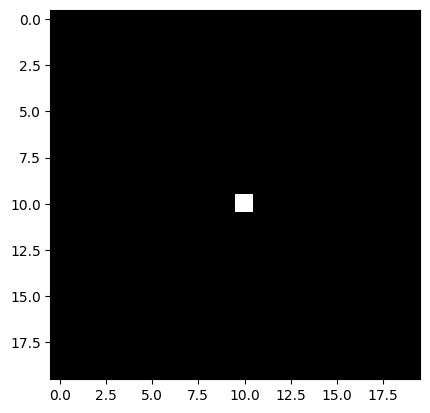

In [3]:
single_dot = np.zeros((20,20))
single_dot[10,10] = 1
plt.imshow(single_dot, cmap = 'gray');

In [4]:
filtered = skimage.filters.gaussian(single_dot)


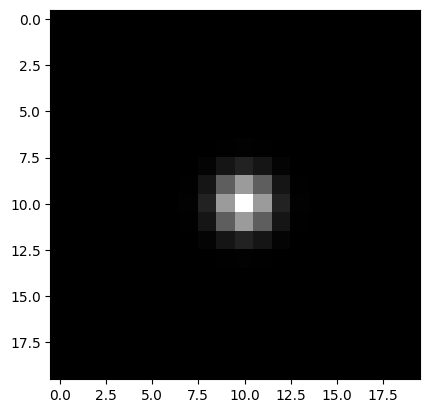

In [5]:
plt.imshow(filtered, cmap = 'gray');


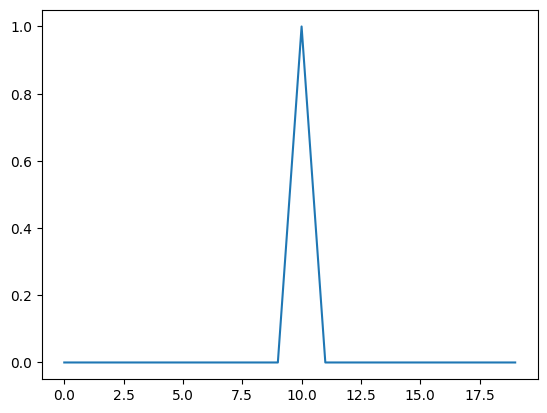

In [6]:
plt.plot(single_dot[10,:]);

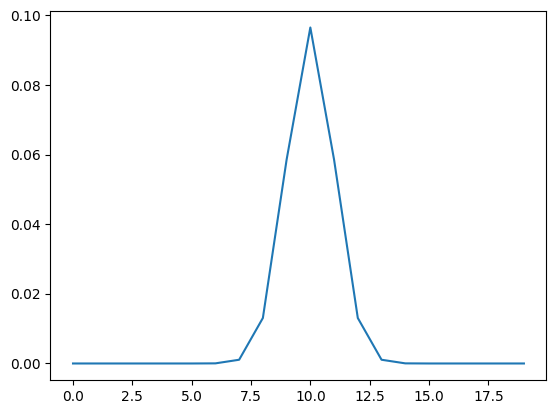

In [7]:
plt.plot(filtered[9,:]);

In [8]:
filtered = skimage.filters.gaussian(single_dot,sigma=4)


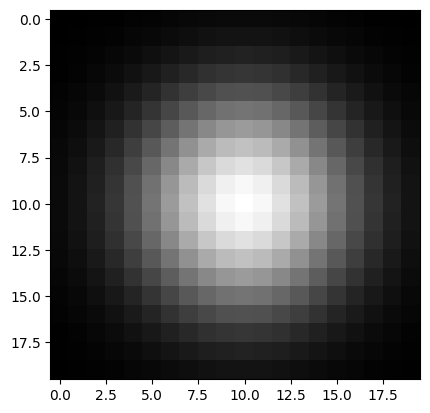

In [9]:
plt.imshow(filtered, cmap = 'gray');


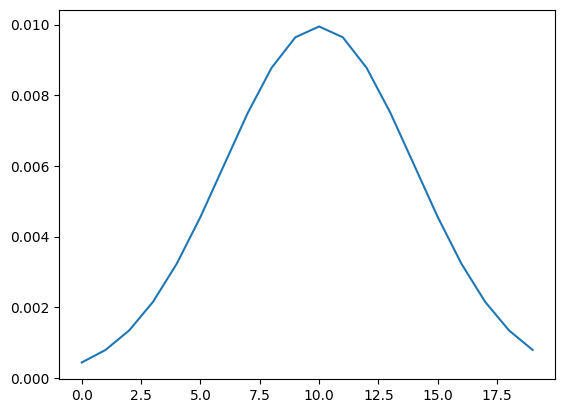

In [10]:
plt.plot(filtered[10,:]);

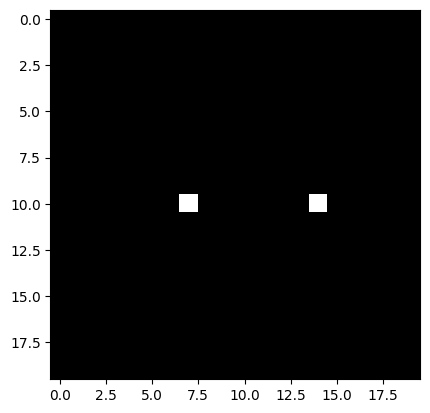

In [11]:
double_dot = np.zeros((20,20))
double_dot[10,7] = 1
double_dot[10,14] = 1
plt.imshow(double_dot, cmap = 'gray');

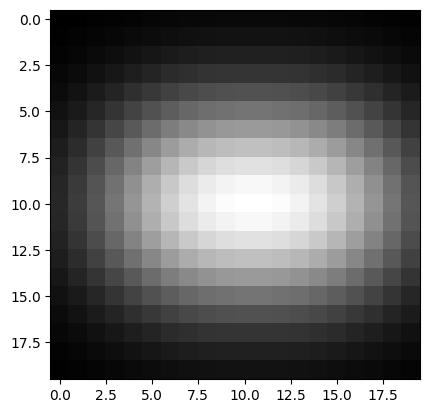

In [12]:
filtered = skimage.filters.gaussian(double_dot,sigma=4)
plt.imshow(filtered, cmap = 'gray');

# Removing noise¶


In [13]:
noisy = filtered + 0.02*np.random.rand(20,20)


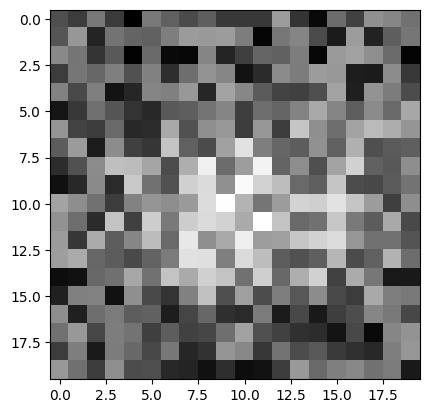

In [14]:
plt.imshow(noisy, cmap = 'gray');


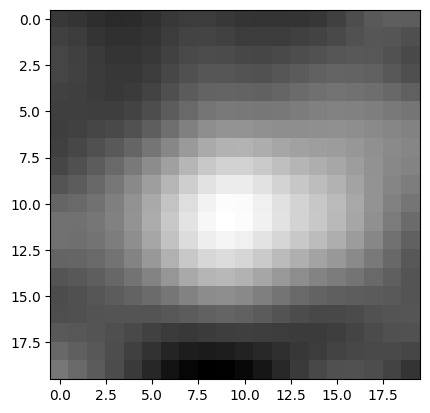

In [15]:
noise_filtered = skimage.filters.gaussian(noisy,sigma=2)  # metode denoising dasar
plt.imshow(noise_filtered, cmap = 'gray');

In [18]:
#image_stack = skimage.io.imread('images/46658_784_B12_1.tif')
GT = skimage.io.imread('01.jpg')

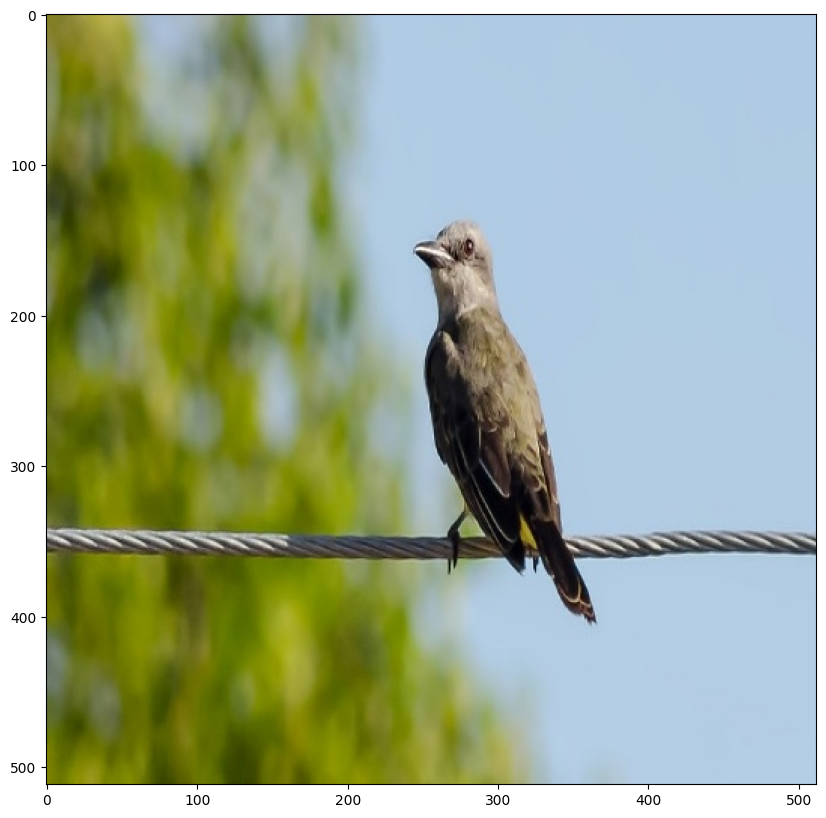

In [19]:
plt.subplots(figsize=(10,10))
plt.imshow(GT);

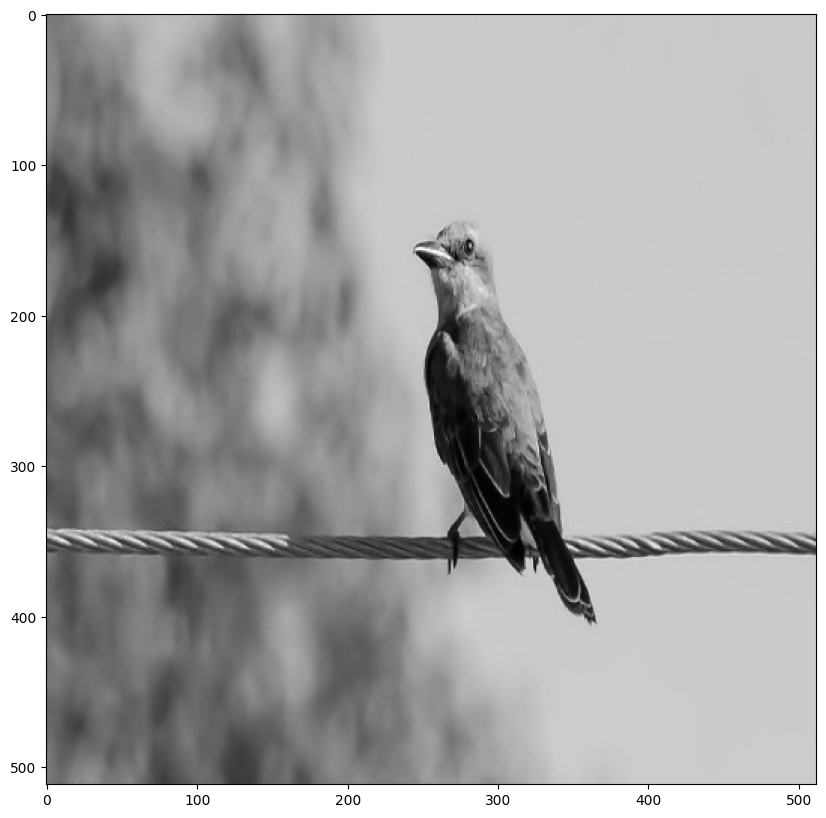

In [20]:
from skimage.color import rgb2gray
GT_gray = rgb2gray(GT)
plt.subplots(figsize=(10,10))
plt.imshow(GT_gray,'gray');

In [23]:
img_noise = skimage.io.imread('01.jpg')

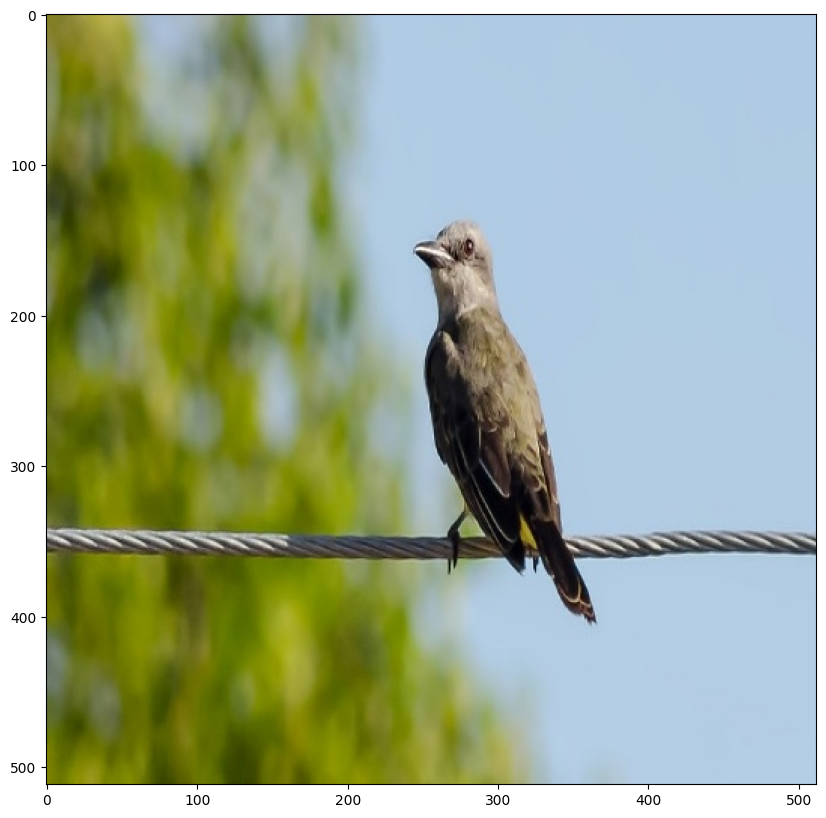

In [24]:
plt.subplots(figsize=(10,10))
plt.imshow(img_noise,'gray');

In [25]:
img_filtered = skimage.filters.gaussian(img_noise, sigma = 2)

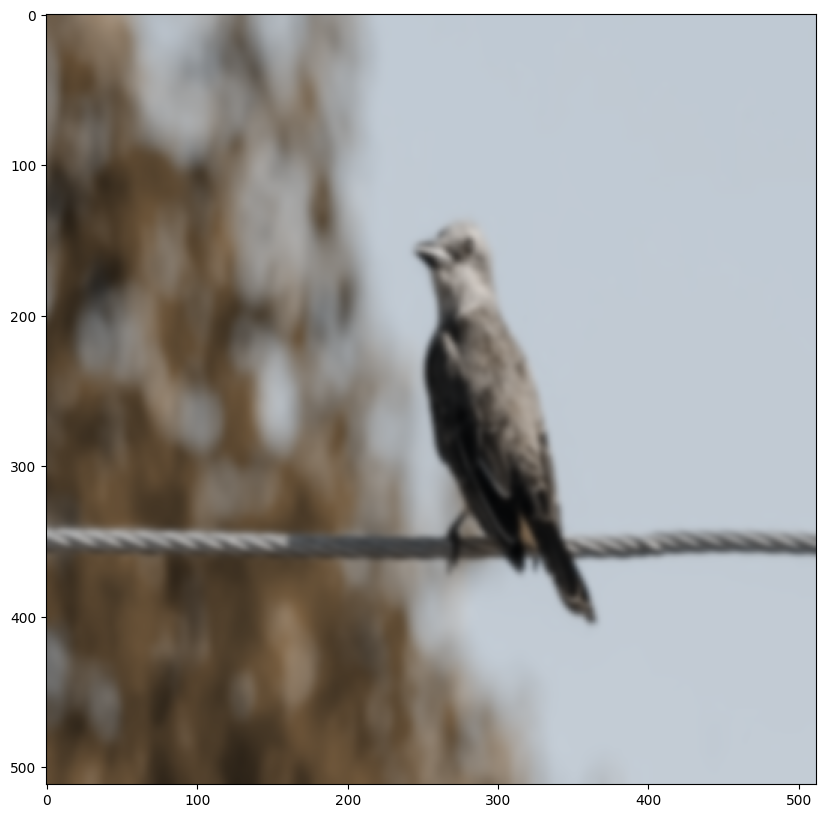

In [26]:
plt.subplots(figsize=(10,10))
plt.imshow(img_filtered,'gray');

In [28]:
print("MSE asli  vs asli :", mse(img_noise, GT_gray))
print("PSNR asli vs asli :", psnr(img_noise, GT_gray), "dB")

print("MSE asli  vs asli :", mse(img_filtered, GT_gray))
print("PSNR asli vs asli :", psnr(img_filtered, GT_gray), "dB")


NameError: name 'mse' is not defined

# Non-linear filters

In [29]:
# memberikan noise dengan metdoe s&d
image_noisy = skimage.util.random_noise(img_noise, mode='s&p')


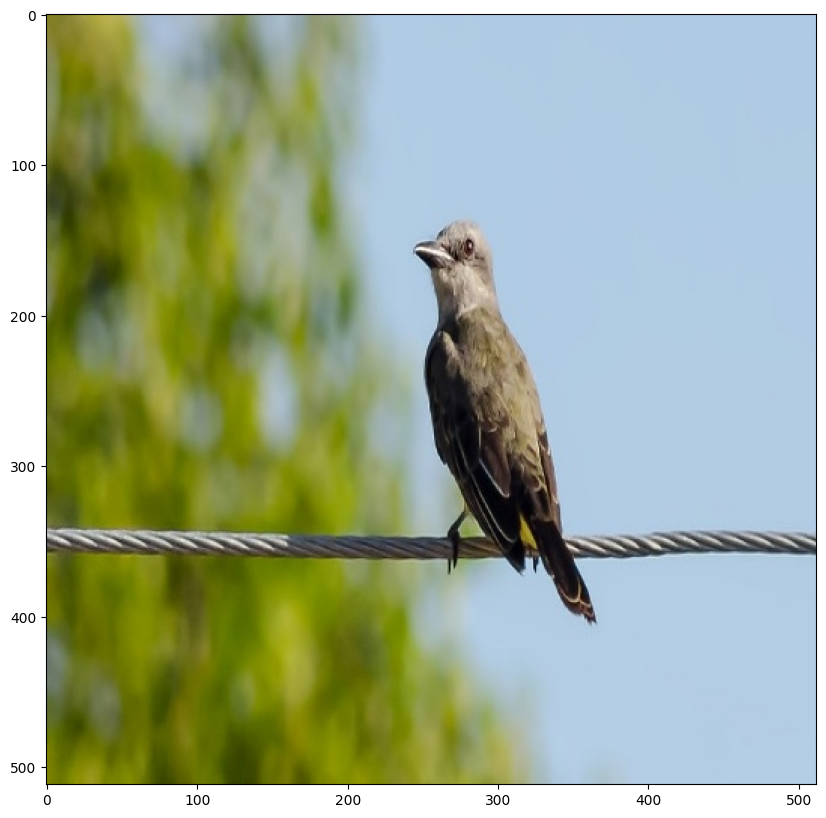

In [30]:
plt.subplots(figsize=(10,10))
plt.imshow(img_noise, cmap = 'gray');

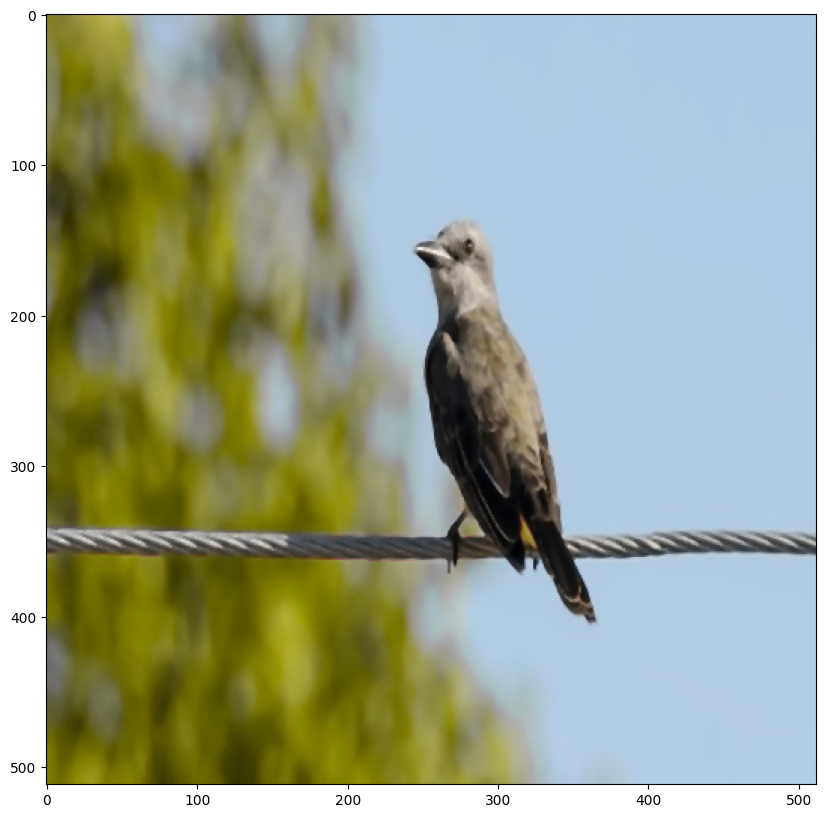

In [31]:
filtered_median = skimage.filters.median(img_noise)

plt.subplots(figsize=(10,10))
plt.imshow(filtered_median, cmap = 'gray');

# MENGECEK TIPE NILAI GT_GRAY
Tipe nilai dari GGT_gray adalah float oleh sebab itu data variabel gambar yang dibandingkan dengan dia harus tipe float juga

In [34]:
GT_gray

array([[0.46334235, 0.46334235, 0.46444353, ..., 0.77953098, 0.77953098,
        0.77953098],
       [0.46726392, 0.46726392, 0.4683651 , ..., 0.77953098, 0.77953098,
        0.77953098],
       [0.47118549, 0.47118549, 0.47620824, ..., 0.77953098, 0.77953098,
        0.77953098],
       ...,
       [0.46916314, 0.46524157, 0.4635749 , ..., 0.79267961, 0.79267961,
        0.79267961],
       [0.46916314, 0.46524157, 0.4635749 , ..., 0.79267961, 0.79267961,
        0.79267961],
       [0.46916314, 0.46916314, 0.4635749 , ..., 0.79267961, 0.79267961,
        0.79267961]], shape=(512, 512))

# MENGECEK TIPE NILAI filtered_median


In [35]:
filtered_median

array([[[126, 124,  38],
        [126, 124,  37],
        [127, 125,  37],
        ...,
        [175, 203, 227],
        [175, 203, 227],
        [175, 203, 227]],

       [[126, 125,  39],
        [127, 125,  38],
        [128, 126,  38],
        ...,
        [175, 203, 227],
        [175, 203, 227],
        [175, 203, 227]],

       [[127, 126,  40],
        [128, 126,  39],
        [129, 127,  39],
        ...,
        [175, 203, 227],
        [175, 203, 227],
        [175, 203, 227]],

       ...,

       [[125, 125,   1],
        [125, 124,   1],
        [124, 122,   0],
        ...,
        [180, 206, 229],
        [180, 206, 229],
        [180, 206, 229]],

       [[125, 125,   1],
        [125, 124,   1],
        [124, 122,   0],
        ...,
        [180, 206, 229],
        [180, 206, 229],
        [180, 206, 229]],

       [[125, 125,   1],
        [125, 125,   1],
        [124, 122,   0],
        ...,
        [180, 206, 229],
        [180, 206, 229],
        [180, 206, 229]]

## Tipe nilai dari filtered_median ternyata uint8 oleh sebab itu harus di normalisasi menjadi float dengan kode program di bawah ini

In [36]:
filtered_median = filtered_median.astype(np.float32)
filtered_median /= 255.

In [37]:
filtered_median

array([[[0.49411765, 0.4862745 , 0.14901961],
        [0.49411765, 0.4862745 , 0.14509805],
        [0.49803922, 0.49019608, 0.14509805],
        ...,
        [0.6862745 , 0.79607844, 0.8901961 ],
        [0.6862745 , 0.79607844, 0.8901961 ],
        [0.6862745 , 0.79607844, 0.8901961 ]],

       [[0.49411765, 0.49019608, 0.15294118],
        [0.49803922, 0.49019608, 0.14901961],
        [0.5019608 , 0.49411765, 0.14901961],
        ...,
        [0.6862745 , 0.79607844, 0.8901961 ],
        [0.6862745 , 0.79607844, 0.8901961 ],
        [0.6862745 , 0.79607844, 0.8901961 ]],

       [[0.49803922, 0.49411765, 0.15686275],
        [0.5019608 , 0.49411765, 0.15294118],
        [0.5058824 , 0.49803922, 0.15294118],
        ...,
        [0.6862745 , 0.79607844, 0.8901961 ],
        [0.6862745 , 0.79607844, 0.8901961 ],
        [0.6862745 , 0.79607844, 0.8901961 ]],

       ...,

       [[0.49019608, 0.49019608, 0.00392157],
        [0.49019608, 0.4862745 , 0.00392157],
        [0.4862745 , 0

## begitu juga Tipe nilai dari img_noise ternyata uint8 oleh sebab itu harus di normalisasi menjadi float dengan kode program di bawah ini

In [38]:
img_noise = img_noise.astype(np.float32)
img_noise /= 255.

In [39]:
img_noise

array([[[0.49411765, 0.4862745 , 0.14509805],
        [0.49411765, 0.4862745 , 0.14509805],
        [0.5019608 , 0.4862745 , 0.13725491],
        ...,
        [0.6862745 , 0.79607844, 0.8901961 ],
        [0.6862745 , 0.79607844, 0.8901961 ],
        [0.6862745 , 0.79607844, 0.8901961 ]],

       [[0.49803922, 0.49019608, 0.14901961],
        [0.49803922, 0.49019608, 0.14901961],
        [0.5058824 , 0.49019608, 0.14117648],
        ...,
        [0.6862745 , 0.79607844, 0.8901961 ],
        [0.6862745 , 0.79607844, 0.8901961 ],
        [0.6862745 , 0.79607844, 0.8901961 ]],

       [[0.5019608 , 0.49411765, 0.15294118],
        [0.5019608 , 0.49411765, 0.15294118],
        [0.5137255 , 0.49803922, 0.14901961],
        ...,
        [0.6862745 , 0.79607844, 0.8901961 ],
        [0.6862745 , 0.79607844, 0.8901961 ],
        [0.6862745 , 0.79607844, 0.8901961 ]],

       ...,

       [[0.49019608, 0.50980395, 0.00392157],
        [0.4862745 , 0.5058824 , 0.        ],
        [0.47843137, 0

In [40]:
print("MSE asli  vs asli :", mse(img_noise, GT_gray))
print("PSNR asli vs asli :", psnr(img_noise, GT_gray), "dB")

print("MSE asli  vs asli :", mse(img_filtered, GT_gray))
print("PSNR asli vs asli :", psnr(img_filtered, GT_gray), "dB")

print("MSE asli  vs asli :", mse(filtered_median, GT_gray))
print("PSNR asli vs asli :", psnr(filtered_median, GT_gray), "dB")


NameError: name 'mse' is not defined

In [41]:
test = skimage.metrics.peak_signal_noise_ratio(GT_gray, filtered_median, *,data_range=None)

SyntaxError: Invalid star expression (3755974770.py, line 1)

# UTS
BUAT SEBUAH METODE FILTERING VERSI KALIAN SENDIRI
GAMBAR UJI
https://www.kaggle.com/datasets/rajneesh231/salt-and-pepper-noise-images

DIPRESENTASIKAN MIBNGGU DEPAN
INDIVIDU